# Feature stat tests

This notebook aims at analyzing the feature differences between high and low entropy transcripts using statistical inference tests.

## Section 1: Imports

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add workflow utilities to path
sys.path.append("/mnt/cbib/LNClassifier/paper/workflow/")
from utils.features import filter_feature_columns, custom_feature_scaling, get_probabilities
from utils.parsing import load_tables
from utils.feature_analysis import (
    perform_mann_whitney_tests, perform_f_tests, perform_mutual_info_tests,
    residualize_features, rank_features_by_composite, rank_features_by_score,
    plot_feature_distributions, plot_feature_heatmap, plot_volcano,
    discover_feature_sets, load_feature_set, correlation_and_distance, cluster_features,
    plot_correlation_heatmap, plot_dendrogram
)

# Plotting configuration
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['pdf.fonttype'] = 42

DATASET = "gencode.v47.common.cdhit.cv"
FIGURE_DIR = f"/mnt/cbib/LNClassifier/paper/results/{DATASET}/features/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

print("✓ Imports successful")


✓ Imports successful


## Section 2: Configuration

In [ ]:
DATASET_NAME = 'gencode.v47.common.cdhit.cv'
BASEDIR = Path("/mnt/cbib/LNClassifier/paper")
FDR_METHOD = 'fdr_bh'  # 'fdr_bh' (recommended), 'bonferroni', 'holm', 'fdr_by'
FDR_ALPHA = 0.01

OUTPUT_DIR = BASEDIR / f'results/{DATASET_NAME}/features/simple_analysis/H_pred_th10-90/'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VERBOSE = True

print(f"✓ Configuration loaded")
print(f"  Dataset: {DATASET_NAME}")
print(f"  Output: {OUTPUT_DIR}")

✓ Configuration loaded
  Dataset: gencode.v47.common.cdhit.cv
  Output: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/simple_analysis/H_pred_th10-90


## Section 3: Load datasets

In [ ]:
def load_dataset(dataset_name, basedir):
    """Load dataset with predictions and labels."""
    tables = load_tables(dataset_name)
    binary = tables['binary'].set_index('seq_ID')
    pc_ids = binary[binary["real"] == True].index.tolist()
    lnc_ids = binary[binary["real"] == False].index.tolist()
    ids_with_class = pc_ids + lnc_ids
    
    features_df = tables['full_table'].set_index('seq_ID')
    features_df = features_df.loc[ids_with_class]
    probs = get_probabilities(features_df)
    probs = probs.dropna()
    
    labels = pd.DataFrame(index=probs.index)
    labels['coding_class'] = labels.index.isin(pc_ids).astype(int)
    labels['biotype'] = labels['coding_class'].map({1: 'coding', 0: 'lncRNA'})
    
    return {
        'probs': probs,
        'labels': labels,
        'features': features_df.loc[probs.index],
        'binary': binary
    }

def load_additional_features(dataset_name, basedir):
    """Load TE and NBD pipeline features if available."""
    additional = {}
    pipelines = {
        'te_pipeline': 'te_pipeline/results/te_analysis_flexible/features/all_transcripts_te_features.corrected.csv',
        'nbd_pipeline': 'nonb-pipeline/results/gencode.v47/extended_analysis/features_nonb_features.corrected.csv',
        'entropy': f"results/{dataset_name}/uncertainty_analysis/{dataset_name}_uncertainty_analysis.tsv"
    }
    
    for key, rel_path in pipelines.items():
        path = basedir / rel_path
        if path.exists():
            ext = path.suffix
            df = pd.read_csv(path, sep='\t' if ext == '.tsv' else ',', index_col=0)
            additional[key] = df
            if VERBOSE:
                print(f"✓ Loaded {key} ({df.shape[0]} samples × {df.shape[1]} features)")
        else:
            if VERBOSE:
                print(f"⚠ {key} not found at {rel_path}")
    
    return additional

# Load main dataset
dataset = load_dataset(DATASET_NAME, BASEDIR)
dataset.update(load_additional_features(DATASET_NAME, BASEDIR))

probs = dataset['probs']
labels = dataset['labels']
features = dataset['features']
features_to_keep = filter_feature_columns(features)
features = features[features_to_keep]
binary = dataset['binary']

# Load additional features if available
if 'te_pipeline' in dataset:
    te_features = dataset['te_pipeline'].loc[probs.index]
    te_features = te_features.fillna(0)
else:
    te_features = None
    print("⚠ TE features not loaded")

if 'nbd_pipeline' in dataset:
    nbd_features = dataset['nbd_pipeline'].loc[probs.index]
    nbd_features.rename(columns={'motif_types_present': 'n_motif_types'}, inplace=True)
else:
    nbd_features = None
    print("⚠ NBD features not loaded")

if 'entropy' in dataset:
    entropy_df = dataset['entropy'].loc[probs.index]
else:
    entropy_df = None
    print("⚠ Entropy metrics not loaded")

print(f"✓ Data loaded: {len(probs)} transcripts with {len(features.columns)} features")

Extracted 8 probability columns.
Inverting noncoding probabilities...
  - Inverting column: Noncoding_prob_ss_lncDC
✓ Loaded te_pipeline (385659 samples × 173 features)
✓ Loaded nbd_pipeline (385659 samples × 189 features)
✓ Loaded entropy (111652 samples × 18 features)
Identified length columns to exclude: ['Transcript_length_lncDC', 'length_plncpro'] (keeping RNA_size_feelnc for reference)
Total number of columns in features table: 172
Number of kept feature columns: 128
Feature columns: ['kmerScore_1mer_feelnc', 'kmerScore_2mer_feelnc', 'kmerScore_3mer_feelnc', 'kmerScore_6mer_feelnc', 'kmerScore_9mer_feelnc', 'kmerScore_12mer_feelnc', 'ORF_cover_feelnc', 'RNA_size_feelnc', 'ORF_l_cpat', 'Fickett_l_cpat', 'Hexamer_l_cpat', 'ORF_coverage_l_cpat', 'GC_content_lncDC', 'Fickett_score_lncDC', 'ORF_T0_length_lncDC', 'ORF_T1_length_lncDC', 'ORF_T2_length_lncDC', 'ORF_T0_coverage_lncDC', 'ORF_T1_coverage_lncDC', 'ORF_T3_coverage_lncDC', 'Hexamer_score_ORF_T0_lncDC', 'Hexamer_score_ORF_T1_ln

In [ ]:
probs

,coding_score_rnasamba,coding_potential_feelnc,Coding_prob_l_cpat,Noncoding_prob_ss_lncDC,coding_prob_mrnn,P(pcRNA)_lncrnabert,prob_coding_plncpro,Coding.Potential_ss_lncfinder
seq_ID,,,,,,,,
ENST00000000412.8,0.99411,0.958,0.933894,0.999833,0.978755,0.999992,0.714,0.989447
ENST00000002596.6,0.98732,0.954,0.996628,0.996186,0.910619,0.999992,0.915,0.995086
ENST00000002829.8,0.99930,1.000,0.998778,0.998462,0.986240,0.999993,0.846,0.970563
ENST00000005260.9,0.99168,0.980,0.980331,0.999546,0.978858,0.999992,0.887,0.959779
ENST00000005995.8,0.97452,0.994,0.942528,0.999394,0.990389,0.999991,0.637,0.891659
...,...,...,...,...,...,...,...,...
ENST00000715715.1,0.04422,0.010,0.171249,0.000282,0.353438,0.000003,0.044,0.059889
ENST00000715718.1,0.00632,0.022,0.289002,0.000984,0.022870,0.000002,0.020,0.112075
ENST00000715720.1,0.24308,0.016,0.172799,0.004180,0.113424,0.000003,0.041,0.049054


### 3.1 Feature pre-processing
- Combine all feature sets
- Remove constant features
- Transform to numeric
- Separate between categorical and continuous

In [ ]:
def remove_constant_features(df, name="Dataset"):
    nunique = df.nunique()
    constant_features = nunique[nunique <= 1].index.tolist()
    if constant_features:
        print(f"{name}: Removing {len(constant_features)} constant features")
        print(f"  Constant features: {constant_features}")
        df = df.drop(columns=constant_features)
    else:
        print(f"{name}: No constant features were removed")
    return df

In [ ]:
original_full = pd.concat([features, te_features, nbd_features], axis=1)
full_feature_set = original_full.copy()
# Since merged df may have duplicate columns:
full_feature_set = full_feature_set.loc[:, ~full_feature_set.columns.duplicated(keep='first')]
# Fill missing values (possible for categorical TE features)
full_feature_set.fillna(0, inplace=True)
# Convert boolean/object columns to numerical (0/1)
full_feature_set = full_feature_set.apply(pd.to_numeric, errors='coerce')

full_feature_set.drop(columns=["transcript_length"], inplace=True)

# Keep only numeric features, and report and remove constant features
numeric_cols = full_feature_set.select_dtypes(include=[np.number]).columns
print(f"Full feature set: keeping {len(numeric_cols)} numeric features (out of {full_feature_set.shape[1]} total)")
numeric_df = full_feature_set[numeric_cols]
full_feature_set = remove_constant_features(numeric_df, name="Full feature set")

Full feature set: keeping 486 numeric features (out of 486 total)
Full feature set: Removing 27 constant features
  Constant features: ['all_numhits_plncpro', 'all_HitScore_plncpro', 'all_Frame_Entropy_plncpro', 'all_Bitscore_plncpro', 'te_has_ervk', 'te_ervk_count', 'te_has_ervl', 'te_ervl_count', 'te_has_ervl-malr', 'te_ervl-malr_count', 'te_has_erv1', 'te_erv1_count', 'pseudo_unique_families', 'te_ervk_count_per_kb', 'te_ervl_count_per_kb', 'te_ervl-malr_count_per_kb', 'te_erv1_count_per_kb', 'transcript_type', 'coding_class', 'apr_transcript_id', 'dr_transcript_id', 'gq_transcript_id', 'ir_transcript_id', 'mr_transcript_id', 'str_transcript_id', 'tri_transcript_id', 'z_transcript_id']


In [ ]:
features

,kmerScore_1mer_feelnc,kmerScore_2mer_feelnc,kmerScore_3mer_feelnc,kmerScore_6mer_feelnc,kmerScore_9mer_feelnc,kmerScore_12mer_feelnc,ORF_cover_feelnc,RNA_size_feelnc,ORF_l_cpat,Fickett_l_cpat,...,Signal.Q2_lncfinder,Signal.Max_lncfinder,Dot_lnc.dist_lncfinder,Dot_pct.dist_lncfinder,Dot_Dist.Ratio_lncfinder,SS.lnc.dist_lncfinder,SS.pct.dist_lncfinder,SS.Dist.Ratio_lncfinder,MFE_lncfinder,UP.PCT_lncfinder
seq_ID,,,,,,,,,,,,,,,,,,,,,
ENST00000000412.8,0.500532,0.500517,0.521942,0.547063,0.550243,0.484597,0.340408,2450.0,834.0,0.9882,...,3.612083,9.503012,-0.035259,-0.038387,0.918522,-0.041452,-0.043689,0.948800,-766.2,0.109024
ENST00000002596.6,0.506236,0.516955,0.552951,0.614614,0.638448,0.500128,0.129050,7160.0,924.0,1.3522,...,9.930891,34.428530,-0.003786,-0.006761,0.560014,-0.010505,-0.012413,0.846316,-2201.2,0.110211
ENST00000002829.8,0.506685,0.516865,0.550626,0.604411,0.633491,0.513626,0.653729,3607.0,2358.0,1.1447,...,5.809128,14.438914,-0.027893,-0.036709,0.759835,-0.026237,-0.031147,0.842343,-1583.8,0.118414
ENST00000005260.9,0.502833,0.508791,0.530998,0.563220,0.573943,0.468130,0.486420,3645.0,1536.0,0.9867,...,5.441633,20.423523,-0.008949,-0.015182,0.589437,-0.014525,-0.018515,0.784500,-1231.3,0.116905
ENST00000005995.8,0.505395,0.513231,0.533184,0.566367,0.577786,0.493292,0.893676,1091.0,945.0,0.9491,...,1.691524,5.218731,-0.108187,-0.132658,0.815534,-0.097378,-0.110237,0.883350,-440.1,0.122936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENST00000715715.1,0.498402,0.497692,0.493839,0.487290,0.453654,0.375686,0.187023,1572.0,294.0,0.5278,...,2.273105,7.508407,-0.043092,-0.053699,0.802472,-0.068444,-0.072700,0.941463,-453.3,0.110757
ENST00000715718.1,0.502086,0.505426,0.503883,0.495754,0.449565,0.332127,0.185593,1180.0,219.0,0.6443,...,1.494416,3.475254,-0.096657,-0.100043,0.966157,-0.128784,-0.126897,1.014876,-315.9,0.111111
ENST00000715720.1,0.508883,0.522687,0.527667,0.548416,0.509664,0.312139,0.089971,4168.0,264.0,0.5106,...,5.608470,23.138216,-0.009223,-0.012621,0.730803,-0.016983,-0.020005,0.848949,-1340.7,0.111831


In [ ]:
# Separate scalar (numeric) from categorical features
categorical_features = []
scalar_features = []

cat_substrings = ['_has_', '_present']

cat_cols = [col for col in full_feature_set.columns if any(sub in col for sub in cat_substrings)]
# Remaining are scalar (numeric)
scalar_cols = full_feature_set.columns.difference(cat_cols).tolist()

if cat_cols:
    categorical_features = full_feature_set[cat_cols]
if scalar_cols:
    scalar_features = full_feature_set[scalar_cols]

if VERBOSE:
    print(f"  Categorical features: {len(cat_cols)} (containing substrings {cat_substrings})")
    print(f"  Scalar features: {len(scalar_cols)}")

  Categorical features: 24 (containing substrings ['_has_', '_present'])
  Scalar features: 435


### 3.2 Obtain entropy groups

In [ ]:
entropy_df

,H_pred,H_exp,I_bald,mean_prob,variance,std,range,ensemble_prob,ensemble_pred,true_label,biotype,n_strong_lnc,n_strong_coding,n_moderate,extreme_disagreement,extreme_agreement,majority_agreement,percentile_group
seq_ID,,,,,,,,,,,,,,,,,,
ENST00000000412.8,0.303135,0.219188,0.083948,0.946004,0.009315,0.096513,0.285992,0.946004,1,1,coding,0,7,1,False,True,True,Middle
ENST00000002596.6,0.197621,0.166846,0.030775,0.969354,0.001432,0.037848,0.089373,0.969354,1,1,coding,0,8,0,False,True,True,Low H_pred / Low I_bald
ENST00000002829.8,0.169100,0.119347,0.049753,0.974917,0.002820,0.053108,0.154000,0.974917,1,1,coding,0,8,0,False,True,True,Low H_pred / Low I_bald
ENST00000005260.9,0.183502,0.157039,0.026462,0.972148,0.001355,0.036809,0.112992,0.972148,1,1,coding,0,8,0,False,True,True,Low H_pred / Low I_bald
ENST00000005995.8,0.370811,0.258398,0.112413,0.928685,0.015272,0.123578,0.362991,0.928685,1,1,coding,0,7,1,False,True,True,Middle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENST00000715715.1,0.420876,0.316363,0.104513,0.085385,0.014785,0.121595,0.353435,0.085385,0,0,lncRNA,7,0,1,False,True,True,Middle
ENST00000715718.1,0.324088,0.236419,0.087669,0.059157,0.009934,0.099667,0.289000,0.059157,0,0,lncRNA,7,0,1,False,True,True,Middle
ENST00000715720.1,0.401976,0.332629,0.069348,0.079942,0.007864,0.088678,0.243077,0.079942,0,0,lncRNA,7,0,1,False,True,True,Middle


In [ ]:
# Simple group definition based on H_pred percentiles
low_perc_th = 0.1
high_perc_th = 0.9
low_th = np.percentile(entropy_df['H_pred'], low_perc_th * 100)
high_th = np.percentile(entropy_df['H_pred'], high_perc_th * 100)
high_th_bald = np.percentile(entropy_df['I_bald'], high_perc_th * 100)

low_mask = entropy_df['H_pred'] <= low_th
high_mask = (entropy_df['H_pred'] >= high_th) & (entropy_df['I_bald'] >= high_th_bald)

low_tx = entropy_df[low_mask].index
high_tx = entropy_df[high_mask].index

## 3.3 Remove any features that became constant only within entropy groups

In [ ]:
scalar_features = remove_constant_features(scalar_features.loc[low_mask | high_mask], name="Scalar features in entropy groups")
categorical_features = remove_constant_features(categorical_features.loc[low_mask | high_mask], name="Categorical features in entropy groups")

Scalar features in entropy groups: Removing 3 constant features
  Constant features: ['pseudo_sum_fragmented', 'te_ple_count', 'te_ple_count_per_kb']
Categorical features in entropy groups: Removing 1 constant features
  Constant features: ['te_has_ple']


## Section 4: Statistical tests

### 4.1 Due diligence on test choices

In [ ]:
from scipy.stats import shapiro, levene
import warnings

warnings.filterwarnings('ignore')

# Test normality for all scalar features using Shapiro-Wilk test
normality_results = []

for col in scalar_features.columns:
    d1_vals = scalar_features.loc[low_tx, col].dropna()
    d2_vals = scalar_features.loc[high_tx, col].dropna()
    
    # Shapiro-Wilk test for normality (H0: data is normally distributed)
    stat_d1, p_d1 = shapiro(d1_vals)
    stat_d2, p_d2 = shapiro(d2_vals)
    
    # Levene's test for equality of variances (H0: variances are equal)
    stat_levene, p_levene = levene(d1_vals, d2_vals)
    
    normality_results.append({
        'feature': col,
        'normality_low_p': p_d1,
        'normality_high_p': p_d2,
        'levene_p': p_levene,
        'normal_both': (p_d1 > 0.05) and (p_d2 > 0.05),
        'equal_var': p_levene > 0.05
    })

normality_df = pd.DataFrame(normality_results).set_index('feature')

# Summary
n_normal_both = normality_df['normal_both'].sum()
n_equal_var = normality_df['equal_var'].sum()

print(f"✓ Normality tests completed for {len(normality_df)} scalar features")
print(f"\nSummary:")
print(f"  Features with BOTH groups normally distributed (p > 0.05): {n_normal_both} / {len(normality_df)} ({100*n_normal_both/len(normality_df):.1f}%)")
print(f"  Features with equal variances (Levene p > 0.05): {n_equal_var} / {len(normality_df)} ({100*n_equal_var/len(normality_df):.1f}%)")
print(f"\n  → Mann-Whitney U test (non-parametric) is appropriate for most features")
print(f"  → T-test could be used only for {n_normal_both} features with both normal distributions")
print(f"\nTop features with worst normality (lowest p-values):")
normality_df[['normality_low_p', 'normality_high_p', 'levene_p', 'normal_both', 'equal_var']].sort_values('normality_low_p').head(20)

✓ Normality tests completed for 432 scalar features

Summary:
  Features with BOTH groups normally distributed (p > 0.05): 0 / 432 (0.0%)
  Features with equal variances (Levene p > 0.05): 61 / 432 (14.1%)

  → Mann-Whitney U test (non-parametric) is appropriate for most features
  → T-test could be used only for 0 features with both normal distributions

Top features with worst normality (lowest p-values):


,normality_low_p,normality_high_p,levene_p,normal_both,equal_var
feature,,,,,
te_rc_count_per_kb,2.149118e-118,1.000000e+00,0.385639,False,True
te_rc_count,2.248290e-118,1.000000e+00,0.316775,False,True
pseudo_scrna_count_per_kb,2.280194e-118,4.943071e-88,0.244839,False,True
pseudo_ancient_count_per_kb,2.406142e-118,4.943071e-88,0.905826,False,True
pseudo_rrna_count_per_kb,2.411315e-118,1.000000e+00,0.252636,False,True
pseudo_min_perc_del,2.450402e-118,6.749588e-88,0.906705,False,True
pseudo_max_perc_del,2.450402e-118,6.749588e-88,0.906705,False,True
pseudo_mean_perc_del,2.450402e-118,6.749588e-88,0.906705,False,True
pseudo_mean_perc_ins,2.482485e-118,5.118981e-88,0.510246,False,True


### 4.2 Tests

In [ ]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import mannwhitneyu, rankdata, chisquare
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.multitest import multipletests

In [ ]:
def vargha_delaney_A(d1, d2):
    """
    Vargha-Delaney A statistic: P(X1 > X2) for unequal sample sizes.

    Parameters:
    -----------
    d1, d2 : array-like
        Two samples to compare

    Returns:
    --------
    float: Probability in range [0, 1]
    """
    n1, n2 = len(d1), len(d2)
    U = mannwhitneyu(d1, d2, method="auto").statistic
    return U / (n1 * n2)

In [ ]:
d1 = scalar_features.loc[low_tx,]
d2 = scalar_features.loc[high_tx,]

stat, pval = mannwhitneyu(d2, d1, alternative="two-sided")
vda = vargha_delaney_A(d2.values, d1.values)
interpretation = [f"{val:.2f} probability of being higher in high entropy group" for val in vda]

mannu_df = pd.DataFrame({
    'statistic': stat,
    'p_value': pval,
    'vda': vda,
    'interpretation': interpretation},
    index=d1.columns)


In [ ]:
n_sign = (mannu_df['p_value'] < 0.05).sum()
print(f"Number of features with significant difference between low and high uncertainty groups (Mann-Whitney U test, p < 0.05): {n_sign} / {len(mannu_df)}")
print(f"")
mannu_df.sort_values('vda', ascending=False)

Number of features with significant difference between low and high uncertainty groups (Mann-Whitney U test, p < 0.05): 359 / 432



,statistic,p_value,vda,interpretation
MFE_lncfinder,39352847.5,0.0,0.944865,0.94 probability of being higher in high entro...
ir_gaps_mean_pct,38661508.0,0.0,0.928266,0.93 probability of being higher in high entro...
ir_mean_length_pct,38605100.0,0.0,0.926911,0.93 probability of being higher in high entro...
ir_gaps_median_pct,38384003.0,0.0,0.921603,0.92 probability of being higher in high entro...
RCB_T0_lncDC,38061878.5,0.0,0.913869,0.91 probability of being higher in high entro...
...,...,...,...,...
Signal.Q1_lncfinder,2136230.0,0.0,0.051291,0.05 probability of being higher in high entro...
SS.pct.dist_lncfinder,2131102.0,0.0,0.051168,0.05 probability of being higher in high entro...
Signal.Min_lncfinder,2122181.0,0.0,0.050954,0.05 probability of being higher in high entro...
RNA_size_feelnc,1941497.0,0.0,0.046615,0.05 probability of being higher in high entro...


In [ ]:
from scipy.stats import chi2_contingency

c1 = categorical_features.loc[low_tx,]
c2 = categorical_features.loc[high_tx]
# Perform chi-squared test for each categorical feature
chi2_results = []
for col in c1.columns:
    contingency_table = pd.crosstab(
        pd.concat([c1[col], c2[col]]),
        pd.concat([pd.Series([0]*len(c1), index=c1.index), pd.Series([1]*len(c2), index=c2.index)])
    )

    if col == 'any_nonb_present' or col == 'lctr_has_simple_repeat':
        print(f"Contingency table for {col}:")
        print(contingency_table)
    
    chi2_stat, chi2_pval, _, _ = chi2_contingency(contingency_table)

    # Calculate Cramér's V for categorical features
    n = len(c1) + len(c2)
    cramers_v = np.sqrt(chi2_stat / (n * (min(contingency_table.shape) - 1))) if min(contingency_table.shape) > 1 else 0

    # Phi
    phi = np.sqrt(chi2_stat / n) if n > 0 else 0

    # Calculate contingency table odds ratio if it's 2x2
    if contingency_table.shape == (2, 2):
        a = contingency_table.iloc[0, 0]  # No & Low Entropy
        b = contingency_table.iloc[0, 1]  # No & High Entropy
        c = contingency_table.iloc[1, 0]  # Yes & Low Entropy
        d = contingency_table.iloc[1, 1]  # Yes & High Entropy
        n = a + b + c + d

        # If any of the counts are zero, we can add 0.5 to all cells (Haldane-Anscombe correction) to avoid infinite odds ratios
        if (b * c) == 0 or (a * d) == 0:
            a += 0.5
            b += 0.5
            c += 0.5
            d += 0.5
            print(f"Applied Haldane-Anscombe correction for {col} due to zero counts")

        odds_ratio = (a * d) / (b * c)
        direction = 'positive' if odds_ratio > 1 else 'negative'
    else:
        odds_ratio = np.nan  # Not defined for non-2x2 tables
        direction = 'undef'
    
    interpretation = f"Odds of having feature in the high entropy group are {odds_ratio:.2f} times the odds in the low entropy group" if not np.isinf(odds_ratio) else f"Odds of having feature in the high entropy group are infinitely higher than in the low entropy group (due to zero counts)"

    chi2_results.append({'feature': col, 'statistic': chi2_stat, 'p_value': chi2_pval, 'cramers_v': cramers_v, 'phi': phi, 'odds_ratio': odds_ratio, 'direction': direction, 'interpretation': interpretation})

chi2_df = pd.DataFrame(chi2_results).set_index('feature')
n_sign_chi2 = (chi2_df['p_value'] < 0.05).sum()
print(f"Number of categorical features with significant difference (Chi-squared test, p < 0.05): {n_sign_chi2} / {len(chi2_df)}")
print("")
chi2_df.sort_values('p_value')


Applied Haldane-Anscombe correction for te_has_rc due to zero counts
Contingency table for lctr_has_simple_repeat:
col_0                      0     1
lctr_has_simple_repeat            
0                       4827  3231
1                       6339   499
Applied Haldane-Anscombe correction for pseudo_has_rrna due to zero counts
Contingency table for any_nonb_present:
col_0                 0     1
any_nonb_present             
0                     0    14
1                 11166  3716
Applied Haldane-Anscombe correction for any_nonb_present due to zero counts
Number of categorical features with significant difference (Chi-squared test, p < 0.05): 15 / 23



,statistic,p_value,cramers_v,phi,odds_ratio,direction,interpretation
feature,,,,,,,
lctr_has_simple_repeat,2118.321235,0.000000e+00,0.377104,0.377104,0.117603,negative,Odds of having feature in the high entropy gro...
z_present,1152.247222,1.457089e-252,0.278124,0.278124,0.216473,negative,Odds of having feature in the high entropy gro...
tri_present,880.289063,1.891447e-193,0.243096,0.243096,0.274278,negative,Odds of having feature in the high entropy gro...
apr_present,645.505503,2.121197e-142,0.208169,0.208169,0.345651,negative,Odds of having feature in the high entropy gro...
dr_present,583.323284,7.099085e-129,0.197888,0.197888,0.212734,negative,Odds of having feature in the high entropy gro...
mr_present,551.580173,5.704783e-122,0.192429,0.192429,0.177239,negative,Odds of having feature in the high entropy gro...
lctr_has_low_complexity,484.735552,1.992088e-107,0.180392,0.180392,0.164416,negative,Odds of having feature in the high entropy gro...
gq_present,438.604847,2.178143e-97,0.171594,0.171594,0.272847,negative,Odds of having feature in the high entropy gro...
str_present,362.169980,9.485953e-81,0.155927,0.155927,0.131014,negative,Odds of having feature in the high entropy gro...


In [ ]:
full_feature_set["te_has_ple"].value_counts()

te_has_ple
0    111647
1         5
Name: count, dtype: int64

In [ ]:
# Example: Contingency table, odds ratio, and effect sizes for lctr_has_simple_repeat
feature_name = 'any_nonb_present'

# Create contingency table
contingency_table = pd.crosstab(
    pd.concat([categorical_features.loc[low_tx, feature_name], categorical_features.loc[high_tx, feature_name]]),
    pd.concat([pd.Series([0]*len(low_tx), index=low_tx), pd.Series([1]*len(high_tx), index=high_tx)]),
    rownames=['has_simple_repeat'],
    colnames=['group']
)
contingency_table.columns = ['Low Entropy', 'High Entropy']
contingency_table.index = ['No', 'Yes']

print(f"Contingency Table for {feature_name}:")
print(contingency_table)
print()

# Calculate odds ratio
a = contingency_table.iloc[0, 0]  # No & Low Entropy
b = contingency_table.iloc[0, 1]  # No & High Entropy
c = contingency_table.iloc[1, 0]  # Yes & Low Entropy
d = contingency_table.iloc[1, 1]  # Yes & High Entropy
n = a + b + c + d

chi2_stat, p_val, dof, expected_freq = chi2_contingency(contingency_table)

# Calculate odds ratio (only for 2×2 tables)
if (b * c) == 0:
    odds_ratio = np.nan
    print(f"Odds Ratio: undefined (zero cell count)")
else:
    odds_ratio = (a * d) / (b * c)
    direction = 'high' if odds_ratio < 1 else 'low'
    opposite_direction = 'low' if odds_ratio < 1 else 'high'
    print(f"Odds Ratio: {odds_ratio:.4f}")
    #print(f"Interpretation: ??? The odds of having simple repeats are {abs(odds_ratio - 1) * 100:.1f}% {'higher' if odds_ratio > 1 else 'lower'} in {direction} entropy group")
    print(f"Interpretation: The odds of having simple repeats in the high entropy group are {odds_ratio:.2f} times the odds in the low entropy group")
    #print(f"Interpretation: ??? The odds of having simple repeats in the low entropy group are {1/odds_ratio:.2f} times the odds in the high entropy group")


print()

# Calculate Phi coefficient (effect size for 2×2 contingency tables)
phi = np.sqrt(chi2_stat / n) if n > 0 else 0
print(f"Phi coefficient (effect size): {phi:.4f}")
print(f"  Interpretation: 0.0-0.1 (negligible), 0.1-0.3 (small), 0.3-0.5 (medium), >0.5 (large)")
print()

# Calculate Cramér's V (generalizes to larger tables)
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n * min_dim)) if min_dim > 0 else 0
print(f"Cramér's V (effect size): {cramers_v:.4f}")
print()

# Chi-squared test results
print(f"Chi-squared statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")
print(f"Degrees of freedom: {dof}")
print(f"Significant (p < 0.05): {p_val < 0.05}")

Contingency Table for any_nonb_present:
     Low Entropy  High Entropy
No             0            14
Yes        11166          3716

Odds Ratio: 0.0000
Interpretation: The odds of having simple repeats in the high entropy group are 0.00 times the odds in the low entropy group

Phi coefficient (effect size): 0.0505
  Interpretation: 0.0-0.1 (negligible), 0.1-0.3 (small), 0.3-0.5 (medium), >0.5 (large)

Cramér's V (effect size): 0.0505

Chi-squared statistic: 38.0472
P-value: 6.9052e-10
Degrees of freedom: 1
Significant (p < 0.05): True


In [ ]:
# Calculate ranks for Mann-Whitney U test
mannu_df['abs_vda'] = abs(mannu_df['vda'] - 0.5)
mannu_df['rank'] = rankdata(mannu_df['abs_vda'])
mannu_df["rank_perc"] = mannu_df["rank"] / len(mannu_df) * 100  # Higher is better

# Calculate ranks for Chi-squared test
chi2_df["rank"] = rankdata(chi2_df['cramers_v'])
chi2_df["rank_perc"] = chi2_df["rank"] / len(chi2_df) * 100  # Higher is better

# Combine results and apply FDR correction
mannu_df['test'] = 'Mann-Whitney U'
chi2_df['test'] = 'Chi-squared'
combined_df = pd.concat([mannu_df, chi2_df], axis=0)
combined_df['adjusted_p_value'] = multipletests(combined_df['p_value'], method=FDR_METHOD, alpha=FDR_ALPHA)[1]
combined_df['significant'] = combined_df['adjusted_p_value'] < FDR_ALPHA
n_sign_fdr = combined_df['significant'].sum()
print(f"Number of features with significant difference after FDR correction (adjusted p < {FDR_ALPHA}): {n_sign_fdr} / {len(combined_df)}")
print("")
combined_df.loc[~combined_df["significant"], "interpretation"] = "Result is not statistically significant after FDR correction"
combined_df = combined_df.sort_values('rank_perc', ascending=False)
combined_df[combined_df["significant"]].head(20)

Number of features with significant difference after FDR correction (adjusted p < 0.01): 369 / 455



,statistic,p_value,vda,interpretation,abs_vda,rank,rank_perc,test,cramers_v,phi,odds_ratio,direction,adjusted_p_value,significant
ORF_T1_length_lncDC,1.937476e+06,0.0,0.046519,0.05 probability of being higher in high entro...,0.453481,432.0,100.000000,Mann-Whitney U,NaN,NaN,NaN,NaN,0.0,True
lctr_has_simple_repeat,2.118321e+03,0.0,NaN,Odds of having feature in the high entropy gro...,NaN,23.0,100.000000,Chi-squared,0.377104,0.377104,0.117603,negative,0.0,True
RNA_size_feelnc,1.941497e+06,0.0,0.046615,0.05 probability of being higher in high entro...,0.453385,431.0,99.768519,Mann-Whitney U,NaN,NaN,NaN,NaN,0.0,True
Signal.Min_lncfinder,2.122181e+06,0.0,0.050954,0.05 probability of being higher in high entro...,0.449046,430.0,99.537037,Mann-Whitney U,NaN,NaN,NaN,NaN,0.0,True
SS.pct.dist_lncfinder,2.131102e+06,0.0,0.051168,0.05 probability of being higher in high entro...,0.448832,429.0,99.305556,Mann-Whitney U,NaN,NaN,NaN,NaN,0.0,True
Signal.Q1_lncfinder,2.136230e+06,0.0,0.051291,0.05 probability of being higher in high entro...,0.448709,428.0,99.074074,Mann-Whitney U,NaN,NaN,NaN,NaN,0.0,True
Signal.Q2_lncfinder,2.158655e+06,0.0,0.051829,0.05 probability of being higher in high entro...,0.448171,427.0,98.842593,Mann-Whitney U,NaN,NaN,NaN,NaN,0.0,True
SS.lnc.dist_lncfinder,2.182593e+06,0.0,0.052404,0.05 probability of being higher in high entro...,0.447596,426.0,98.611111,Mann-Whitney U,NaN,NaN,NaN,NaN,0.0,True
MFE_lncfinder,3.935285e+07,0.0,0.944865,0.94 probability of being higher in high entro...,0.444865,425.0,98.379630,Mann-Whitney U,NaN,NaN,NaN,NaN,0.0,True
Signal.Max_lncfinder,2.349596e+06,0.0,0.056414,0.06 probability of being higher in high entro...,0.443586,424.0,98.148148,Mann-Whitney U,NaN,NaN,NaN,NaN,0.0,True


## 5. Output tables

### 5.1 Save output csv for downstream analysis

In [ ]:
combined_df[combined_df["significant"]].to_csv(OUTPUT_DIR / "feature_statistical_tests_results.csv")

In [ ]:
# Set pandas display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### Combined table, top 20 combined raw features

In [ ]:
tidy_columns = ["adjusted_p_value", "rank_perc", "test", "vda", "cramers_v", "odds_ratio", "interpretation", "significant"]
tidy_results = combined_df[tidy_columns]
tidy_results.head(20)

,adjusted_p_value,rank_perc,test,vda,cramers_v,odds_ratio,interpretation,significant
ORF_T1_length_lncDC,0.0,100.000000,Mann-Whitney U,0.046519,NaN,NaN,0.05 probability of being higher in high entropy group,True
lctr_has_simple_repeat,0.0,100.000000,Chi-squared,NaN,0.377104,0.117603,Odds of having feature in the high entropy group are 0.12 times the odds in the low entropy group,True
RNA_size_feelnc,0.0,99.768519,Mann-Whitney U,0.046615,NaN,NaN,0.05 probability of being higher in high entropy group,True
Signal.Min_lncfinder,0.0,99.537037,Mann-Whitney U,0.050954,NaN,NaN,0.05 probability of being higher in high entropy group,True
SS.pct.dist_lncfinder,0.0,99.305556,Mann-Whitney U,0.051168,NaN,NaN,0.05 probability of being higher in high entropy group,True
Signal.Q1_lncfinder,0.0,99.074074,Mann-Whitney U,0.051291,NaN,NaN,0.05 probability of being higher in high entropy group,True
Signal.Q2_lncfinder,0.0,98.842593,Mann-Whitney U,0.051829,NaN,NaN,0.05 probability of being higher in high entropy group,True
SS.lnc.dist_lncfinder,0.0,98.611111,Mann-Whitney U,0.052404,NaN,NaN,0.05 probability of being higher in high entropy group,True
MFE_lncfinder,0.0,98.379630,Mann-Whitney U,0.944865,NaN,NaN,0.94 probability of being higher in high entropy group,True
Signal.Max_lncfinder,0.0,98.148148,Mann-Whitney U,0.056414,NaN,NaN,0.06 probability of being higher in high entropy group,True


### Continuous variable table, top 20 raw significant features

In [ ]:
tidy_results[(tidy_results["test"] == "Mann-Whitney U") & (tidy_results["significant"] == True)].head(20)

,adjusted_p_value,rank_perc,test,vda,cramers_v,odds_ratio,interpretation,significant
ORF_T1_length_lncDC,0.0,100.000000,Mann-Whitney U,0.046519,NaN,NaN,0.05 probability of being higher in high entropy group,True
RNA_size_feelnc,0.0,99.768519,Mann-Whitney U,0.046615,NaN,NaN,0.05 probability of being higher in high entropy group,True
Signal.Min_lncfinder,0.0,99.537037,Mann-Whitney U,0.050954,NaN,NaN,0.05 probability of being higher in high entropy group,True
SS.pct.dist_lncfinder,0.0,99.305556,Mann-Whitney U,0.051168,NaN,NaN,0.05 probability of being higher in high entropy group,True
Signal.Q1_lncfinder,0.0,99.074074,Mann-Whitney U,0.051291,NaN,NaN,0.05 probability of being higher in high entropy group,True
Signal.Q2_lncfinder,0.0,98.842593,Mann-Whitney U,0.051829,NaN,NaN,0.05 probability of being higher in high entropy group,True
SS.lnc.dist_lncfinder,0.0,98.611111,Mann-Whitney U,0.052404,NaN,NaN,0.05 probability of being higher in high entropy group,True
MFE_lncfinder,0.0,98.379630,Mann-Whitney U,0.944865,NaN,NaN,0.94 probability of being higher in high entropy group,True
Signal.Max_lncfinder,0.0,98.148148,Mann-Whitney U,0.056414,NaN,NaN,0.06 probability of being higher in high entropy group,True
Dot_pct.dist_lncfinder,0.0,97.916667,Mann-Whitney U,0.057478,NaN,NaN,0.06 probability of being higher in high entropy group,True


### Categorical variable table, top 20 raw features

In [ ]:
tidy_results[(tidy_results["test"] == 'Chi-squared') & (tidy_results["significant"] == True)].head(20)

,adjusted_p_value,rank_perc,test,vda,cramers_v,odds_ratio,interpretation,significant
lctr_has_simple_repeat,0.000000e+00,100.000000,Chi-squared,NaN,0.377104,0.117603,Odds of having feature in the high entropy group are 0.12 times the odds in the low entropy group,True
z_present,5.524794e-252,95.652174,Chi-squared,NaN,0.278124,0.216473,Odds of having feature in the high entropy group are 0.22 times the odds in the low entropy group,True
tri_present,6.147204e-193,91.304348,Chi-squared,NaN,0.243096,0.274278,Odds of having feature in the high entropy group are 0.27 times the odds in the low entropy group,True
apr_present,5.885028e-142,86.956522,Chi-squared,NaN,0.208169,0.345651,Odds of having feature in the high entropy group are 0.35 times the odds in the low entropy group,True
dr_present,1.922669e-128,82.608696,Chi-squared,NaN,0.197888,0.212734,Odds of having feature in the high entropy group are 0.21 times the odds in the low entropy group,True
mr_present,1.500391e-121,78.260870,Chi-squared,NaN,0.192429,0.177239,Odds of having feature in the high entropy group are 0.18 times the odds in the low entropy group,True
lctr_has_low_complexity,5.092136e-107,73.913043,Chi-squared,NaN,0.180392,0.164416,Odds of having feature in the high entropy group are 0.16 times the odds in the low entropy group,True
gq_present,5.299760e-97,69.565217,Chi-squared,NaN,0.171594,0.272847,Odds of having feature in the high entropy group are 0.27 times the odds in the low entropy group,True
str_present,2.136687e-80,65.217391,Chi-squared,NaN,0.155927,0.131014,Odds of having feature in the high entropy group are 0.13 times the odds in the low entropy group,True
te_has_dna,1.197637e-57,60.869565,Chi-squared,NaN,0.131471,0.328016,Odds of having feature in the high entropy group are 0.33 times the odds in the low entropy group,True


### Continuous variable table, all raw features

In [ ]:
mann_tidy_columns = ["adjusted_p_value", "rank_perc", "test", "vda", "interpretation", "significant"]
combined_df.loc[(combined_df["test"] == 'Mann-Whitney U'), mann_tidy_columns]

,adjusted_p_value,rank_perc,test,vda,interpretation,significant
ORF_T1_length_lncDC,0.000000e+00,100.000000,Mann-Whitney U,0.046519,0.05 probability of being higher in high entropy group,True
RNA_size_feelnc,0.000000e+00,99.768519,Mann-Whitney U,0.046615,0.05 probability of being higher in high entropy group,True
Signal.Min_lncfinder,0.000000e+00,99.537037,Mann-Whitney U,0.050954,0.05 probability of being higher in high entropy group,True
SS.pct.dist_lncfinder,0.000000e+00,99.305556,Mann-Whitney U,0.051168,0.05 probability of being higher in high entropy group,True
Signal.Q1_lncfinder,0.000000e+00,99.074074,Mann-Whitney U,0.051291,0.05 probability of being higher in high entropy group,True
Signal.Q2_lncfinder,0.000000e+00,98.842593,Mann-Whitney U,0.051829,0.05 probability of being higher in high entropy group,True
SS.lnc.dist_lncfinder,0.000000e+00,98.611111,Mann-Whitney U,0.052404,0.05 probability of being higher in high entropy group,True
MFE_lncfinder,0.000000e+00,98.379630,Mann-Whitney U,0.944865,0.94 probability of being higher in high entropy group,True
Signal.Max_lncfinder,0.000000e+00,98.148148,Mann-Whitney U,0.056414,0.06 probability of being higher in high entropy group,True
Dot_pct.dist_lncfinder,0.000000e+00,97.916667,Mann-Whitney U,0.057478,0.06 probability of being higher in high entropy group,True


### Categorical variable table, all raw features

In [ ]:
chi_tidy_columns = ["adjusted_p_value", "rank_perc", "test", "cramers_v", "odds_ratio", "interpretation", "significant"]
combined_df.loc[combined_df["test"] == "Chi-squared", chi_tidy_columns].head(20)

,adjusted_p_value,rank_perc,test,cramers_v,odds_ratio,interpretation,significant
lctr_has_simple_repeat,0.000000e+00,100.000000,Chi-squared,0.377104,0.117603,Odds of having feature in the high entropy group are 0.12 times the odds in the low entropy group,True
z_present,5.524794e-252,95.652174,Chi-squared,0.278124,0.216473,Odds of having feature in the high entropy group are 0.22 times the odds in the low entropy group,True
tri_present,6.147204e-193,91.304348,Chi-squared,0.243096,0.274278,Odds of having feature in the high entropy group are 0.27 times the odds in the low entropy group,True
apr_present,5.885028e-142,86.956522,Chi-squared,0.208169,0.345651,Odds of having feature in the high entropy group are 0.35 times the odds in the low entropy group,True
dr_present,1.922669e-128,82.608696,Chi-squared,0.197888,0.212734,Odds of having feature in the high entropy group are 0.21 times the odds in the low entropy group,True
mr_present,1.500391e-121,78.260870,Chi-squared,0.192429,0.177239,Odds of having feature in the high entropy group are 0.18 times the odds in the low entropy group,True
lctr_has_low_complexity,5.092136e-107,73.913043,Chi-squared,0.180392,0.164416,Odds of having feature in the high entropy group are 0.16 times the odds in the low entropy group,True
gq_present,5.299760e-97,69.565217,Chi-squared,0.171594,0.272847,Odds of having feature in the high entropy group are 0.27 times the odds in the low entropy group,True
str_present,2.136687e-80,65.217391,Chi-squared,0.155927,0.131014,Odds of having feature in the high entropy group are 0.13 times the odds in the low entropy group,True
te_has_dna,1.197637e-57,60.869565,Chi-squared,0.131471,0.328016,Odds of having feature in the high entropy group are 0.33 times the odds in the low entropy group,True


## 6. Graphs

### 6.1 Categorical variables

In [ ]:
chi2_label_dict = {'te_has_ltr': 'LTR',
 'gq_present': 'G-Quadruplex',
 'lctr_has_simple_repeat': 'Simple Repeat',
 'z_present': 'Z-DNA',
 'te_has_line': 'LINE',
 'tri_present': 'Triplex DNA',
 'dr_present': 'Direct Repeat',
 'mr_present': 'Mirror Repeat',
 'str_present': 'Short Tandem Repeat',
 'lctr_has_low_complexity': 'Low Complexity Region',
 'apr_present': 'A-Phased Repeat',
 'te_has_dna': 'DNA Transposon'
 }

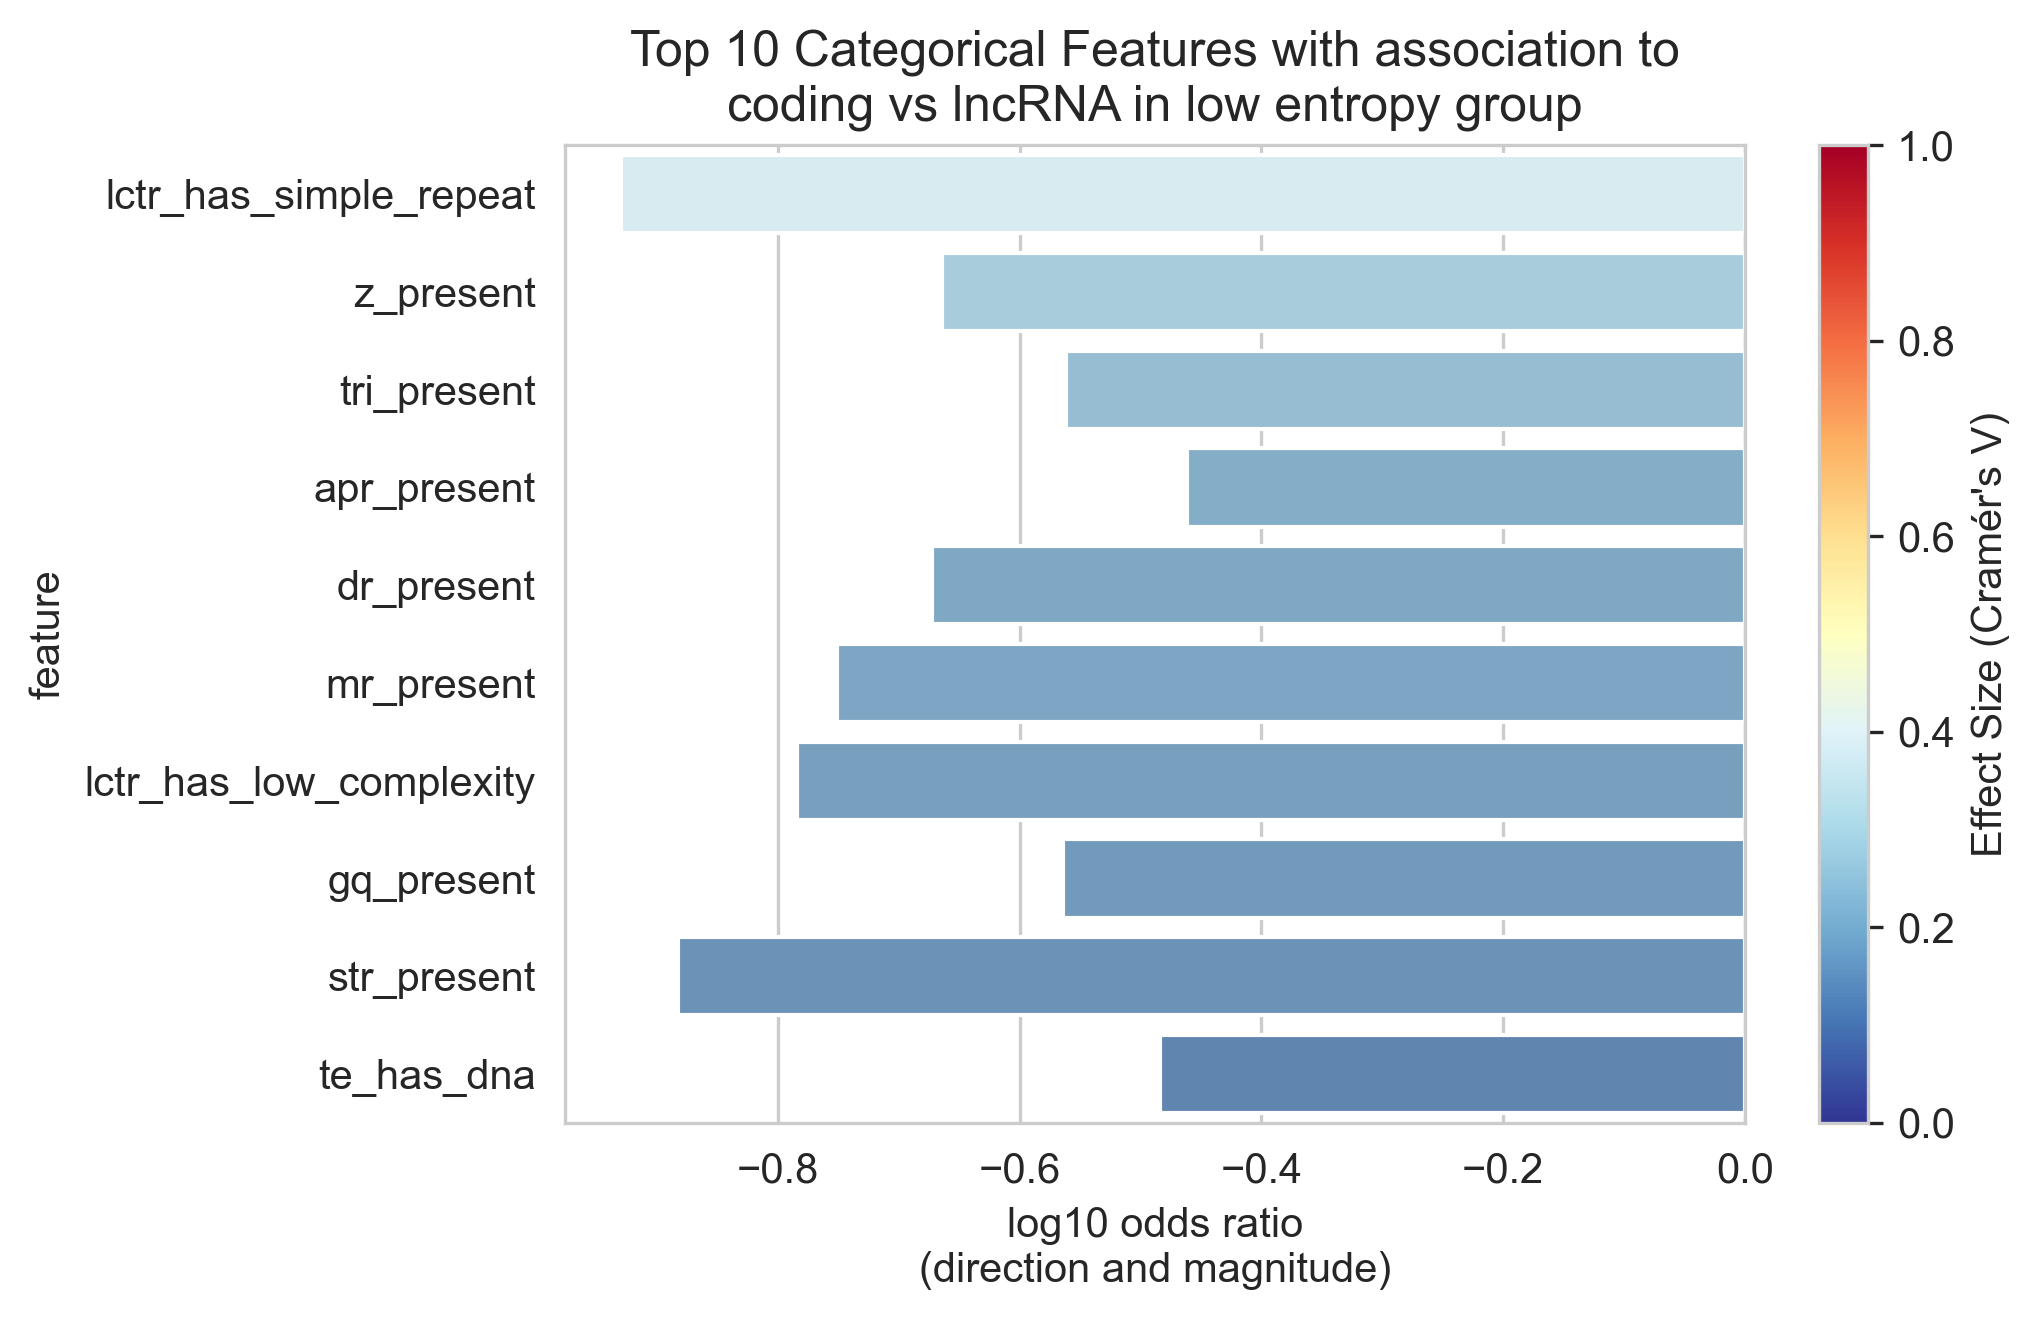

In [ ]:
# Select top 10 categorical features by Cramér's V
top10 = chi2_df.sort_values('cramers_v', ascending=False).head(10).copy()

top10['label'] = top10.index.map(chi2_label_dict)
# Prepare color values (odds_ratio): replace inf and NaN with 1 (neutral)
#top10['odds_ratio_clean'] = top10['odds_ratio'].replace([np.inf, -np.inf], np.nan).fillna(1.0)

top10["log10_odds_ratio"] = np.log10(top10["odds_ratio"].replace(0, np.nan))

# Plot
y_pos = np.arange(len(top10))[::-1]  # highest rank at top
fig, ax = plt.subplots(figsize=(7, 4.5))
sc = sns.barplot(x=top10['log10_odds_ratio'], y=top10.index[::-1], hue=top10['cramers_v'], palette='RdYlBu_r', hue_norm=(0,1), ax=ax)


ax.set_yticks(y_pos)
ax.set_yticklabels(top10.index[::-1])
ax.set_xlabel("log10 odds ratio\n(direction and magnitude)")
ax.set_title("Top 10 Categorical Features with association to\ncoding vs lncRNA in low entropy group")

# cbar = plt.colorbar(sc, ax=ax)
# cbar.set_label("Effect Size (Cramér's V)")

#norm = plt.Normalize(top10["cramers_v"].min(), top10["cramers_v"].max())
cmap = sns.color_palette('RdYlBu_r', as_cmap=True)
sm = plt.cm.ScalarMappable(cmap=cmap)
# Use seaborn RdYlBy_r colormap instead of matplotlib's default


ax.get_legend().remove()
ax.figure.colorbar(sm, ax=ax).set_label("Effect Size (Cramér's V)")

plt.tight_layout()
plt.show()

In [ ]:
sns.set_theme(style="whitegrid",
              font="Arial",
              rc={
                  "figure.dpi": 300,
                    "axes.titlesize": 6,
                    "axes.labelsize": 6,
                    "xtick.labelsize": 6,
                    "ytick.labelsize": 6,
                    "font.size": 6,
                    "legend.fontsize": 6,
                    "lines.linewidth": 0.5,
                    "axes.linewidth": 0.5,
                    "patch.linewidth": 0.5,
                    "axes.edgecolor": "black",
                    "grid.linewidth": 0.5,
                    "figure.edgecolor": "black",
                    "xtick.major.width": 0.5,
                    "ytick.major.width": 0.5,
                    "xtick.major.size": 3,
                    "ytick.major.size": 3
                  }
              )


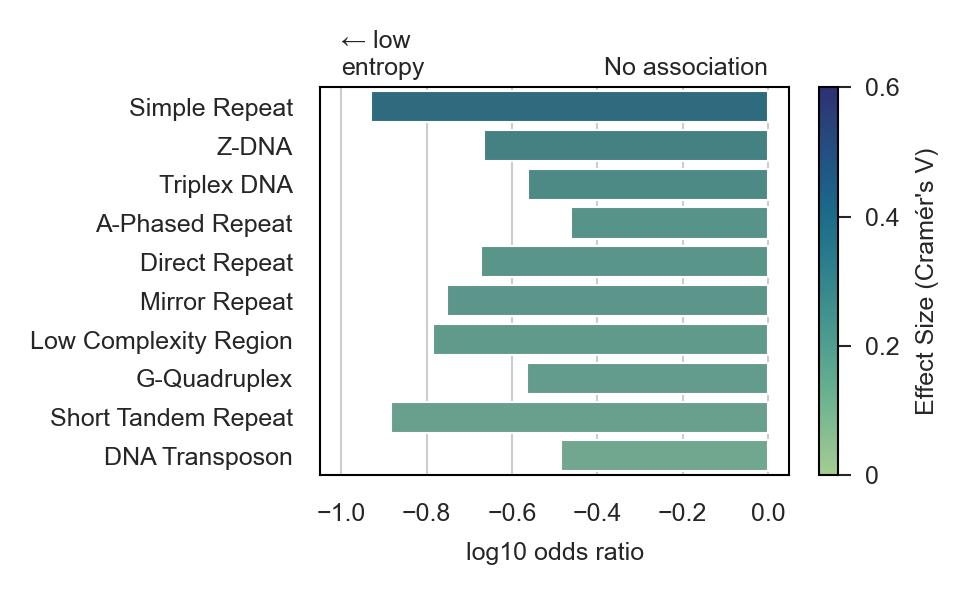

In [ ]:
# Select top 10 categorical features by Cramér's V
top10 = chi2_df.sort_values('cramers_v', ascending=False).head(10).copy()

top10['label'] = top10.index.map(chi2_label_dict)
top10["log10_odds_ratio"] = np.log10(top10["odds_ratio"].replace(0, np.nan))

# Colors
norm = plt.Normalize(0, 0.6)
cmap = sns.color_palette("crest", as_cmap=True)
#cmap = sns.color_palette('RdYlBu_r', as_cmap=True)
#cmap = plt.cm.Blues

fig_h_cm = 5
fig_w_cm = 8

# Plot
fig, ax = plt.subplots(figsize=(fig_w_cm / 2.54 , fig_h_cm/2.54), dpi=300)
bar = sns.barplot(x=top10['log10_odds_ratio'], y=top10.index[::-1], hue=top10['cramers_v'], palette=cmap, hue_norm=norm, ax=ax)

y_pos = np.arange(len(top10))[::-1]  # highest rank at top
ax.set_yticks(y_pos)
ax.set_yticklabels(top10['label'][::-1])
#ax.set_ylabel("Presence of feature")
ax.set_ylabel("")
ax.set_xlabel("log10 odds ratio")
#ax.set_title("Top 10 Categorical Features with association to\ncoding vs lncRNA in low entropy group", pad=30)

ax.set_xlim(-1.05, 0.05)

#Add annotation on top of graph with direction
#Right is pc, left is lncRNA, 0 shows no association
#ax.text(1.2, 1.02, 'coding →', ha='right', va='bottom', transform=ax.get_xaxis_transform())
ax.text(-1.0, 1.02, '← low\nentropy', ha='left', va='bottom', transform=ax.get_xaxis_transform())
ax.text(0, 1.02, 'No association', ha='right', va='bottom', transform=ax.get_xaxis_transform())

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
ax.get_legend().remove()
cbar = ax.figure.colorbar(sm, ax=ax)
cbar.set_label("Effect Size (Cramér's V)")
cbar.set_ticks([0, 0.2, 0.4, 0.6])
#cbar.set_ticklabels(['0', '0.2 (mild)', '0.4 (medium)', '0.6 (strong)'])
cbar.set_ticklabels(['0', '0.2', '0.4', '0.6'])

plt.savefig(os.path.join(FIGURE_DIR, "univariate_chi2_entropy.pdf"), dpi=300, format='pdf')

plt.tight_layout()
plt.show()

#### Frequencies

In [ ]:
# Calculate frequencies for categorical features by entropy group
feature_frequencies = []

for feature in top10.index:
    # Low entropy group
    low_entropy = categorical_features.loc[low_tx, feature]
    
    # High entropy group
    high_entropy = categorical_features.loc[high_tx, feature]
    
    feature_frequencies.append({
        'feature': feature,
        'low_entropy_freq': low_entropy.sum() / len(low_entropy) * 100,
        'high_entropy_freq': high_entropy.sum() / len(high_entropy) * 100,
        'low_entropy_n': len(low_entropy),
        'high_entropy_n': len(high_entropy)
    })
    
    freq_df = pd.DataFrame(feature_frequencies).set_index('feature')

# Add labels
freq_df['label'] = freq_df.index.map(chi2_label_dict)

# Reorder by top10 order (highest Cramér's V first)
freq_df = freq_df.loc[top10.index]

print("Feature frequencies by class and entropy group:")
print(freq_df[['label', 'low_entropy_freq', 'high_entropy_freq']].round(1))


Feature frequencies by class and entropy group:
                                         label  low_entropy_freq  \
feature                                                            
lctr_has_simple_repeat           Simple Repeat              56.8   
z_present                                Z-DNA              90.5   
tri_present                        Triplex DNA              87.9   
apr_present                    A-Phased Repeat              83.9   
dr_present                       Direct Repeat              96.5   
mr_present                       Mirror Repeat              97.7   
lctr_has_low_complexity  Low Complexity Region              18.2   
gq_present                        G-Quadruplex              95.6   
str_present                Short Tandem Repeat              99.2   
te_has_dna                      DNA Transposon              16.8   

                         high_entropy_freq  
feature                                     
lctr_has_simple_repeat                13.4  


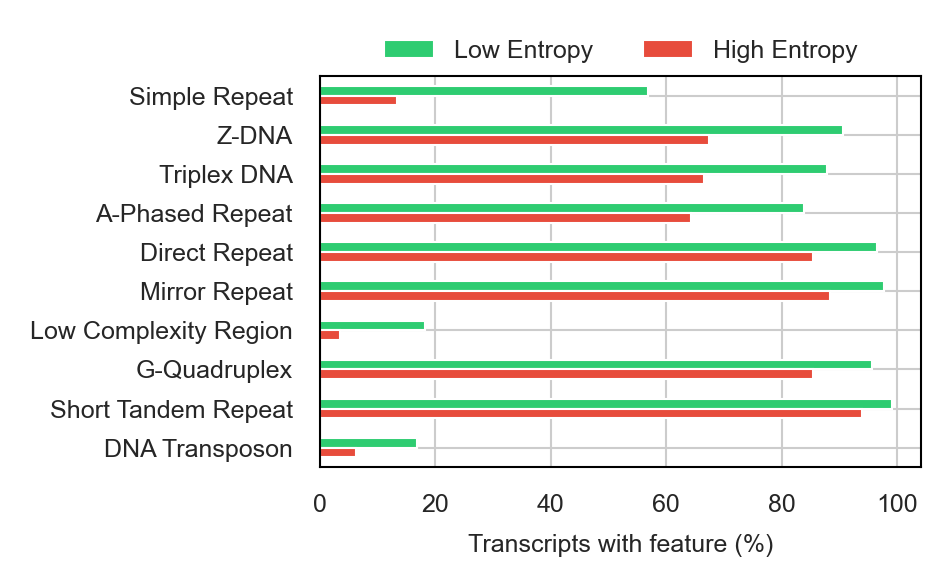

In [ ]:
fig_h_cm = 5
fig_w_cm = 8

freq_df = freq_df.rename(columns={'low_entropy_freq': 'Low Entropy', 'high_entropy_freq': 'High Entropy'})

fig, ax = plt.subplots(figsize=(fig_w_cm/2.54, fig_h_cm/2.54), dpi=300)
freq_df.plot.barh(x='label', y=['Low Entropy', 'High Entropy'], ax=ax, color=['#2ecc71', '#e74c3c'])

ax.invert_yaxis()

ax.set_xlabel("Transcripts with feature (%)")
#ax.set_ylabel("Presence of feature")
ax.set_ylabel("")

ax.legend(title="", loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)

plt.savefig(os.path.join(FIGURE_DIR, "proportions_chi2_entropy.pdf"), dpi=300, format='pdf')

plt.tight_layout()
plt.show()

### 6.2 Continuous variables

In [ ]:
mannu_to_plot = combined_df.loc[(combined_df["test"] == 'Mann-Whitney U'), mann_tidy_columns + ["abs_vda"]].sort_values('abs_vda', ascending=False).head(10)
mannu_to_plot.columns

Index(['adjusted_p_value', 'rank_perc', 'test', 'vda', 'interpretation',
       'significant', 'abs_vda'],
      dtype='object')

In [ ]:
mannu_dict = {
'ORF_T1_length_lncDC': 'ORF length (type 1)',
 'RNA_size_feelnc': 'Transcript length',
 'Signal.Min_lncfinder': 'Minimum frame signal',
 'SS.pct.dist_lncfinder': 'Distance to coding SS',
 'Signal.Q1_lncfinder': 'Q1 of frame signal',
 'Signal.Q2_lncfinder': 'Q2 of frame signal',
 'SS.lnc.dist_lncfinder': 'Distance to lncRNA SS',
 'MFE_lncfinder': 'Minimum free energy',
 'Signal.Max_lncfinder': 'Maximum frame signal',
 'Dot_pct.dist_lncfinder': 'Distance to coding SS (dot format)',
 'ORF_T0_MW_lncDC': 'ORF Mol. Weight (type 1)',
 'ORF_T0_length_lncDC': 'ORF length (type 0)',
 'ORF_l_cpat': 'ORF length (CPAT)',
 'ORF.Max.Len_lncfinder': 'Max. ORF length',
 'Seq.pct.Dist_lncfinder': 'Distance to coding seqs.',
 'Seq.lnc.Dist_lncfinder': 'Distance to lncRNA seqs.',
 'Fickett_l_cpat': 'Fickett score (CPAT)',
 'Hexamer_l_cpat': 'Hexamer score (CPAT)',
 'Signal.Peak_lncfinder': 'Peak frame signal',
 'RCB_T0_lncDC': 'ORF relative codon bias (type 0)',
 'global_gaps_max': 'Longest gap between rep. elements',
 'SS.Dist.Ratio_lncfinder': 'Distance ratio (lncRNA SS/coding SS)',
 'total_nonb_count': 'Total non-B DNA motifs',
 'ORF_T0_coverage_lncDC': 'ORF coverage (type 0)',
 'RCB_T1_lncDC': 'ORF relative codon bias (type 1)',
 'ORF_T2_MW_lncDC': 'ORF Mol. Weight (type 2)',
 'Hexamer_score_ORF_T0_lncDC': 'Hexamer score (ORF type 0)',
 'ir_gaps_mean_pct': 'Mean gap cvg. between IRs',
 'str_mean_length_pct': 'Mean coverage of STRs',
 'ir_max_length_pct': 'Max coverage of an IR',
 'str_max_length_pct': 'Max coverage of a STR',
}

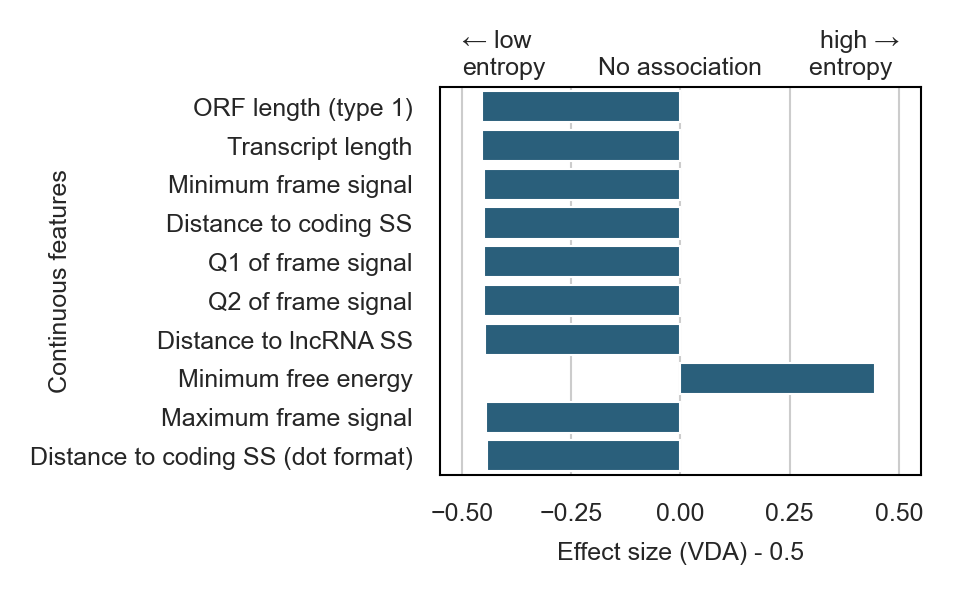

In [ ]:
# Select top 10 categorical features by Cramér's V
top10 = mannu_to_plot
top10["vda_to_plot"] = top10["vda"] - 0.5  # Center around 0 for better color mapping

top10['label'] = top10.index.map(mannu_dict)
top10['label'] = top10['label'].fillna(top10.index.to_series())
#top10["log10_odds_ratio"] = np.log10(top10["odds_ratio"].replace(0, np.nan))

# Colors
norm = plt.Normalize(0, 0.6)
cmap = sns.color_palette("crest")
#cmap = sns.color_palette('RdYlBu_r', as_cmap=True)
#cmap = plt.cm.Blues

fig_h_cm = 5
fig_w_cm = 8

# Plot
fig, ax = plt.subplots(figsize=(fig_w_cm / 2.54 , fig_h_cm/2.54), dpi=300)
bar = sns.barplot(x=top10['vda_to_plot'], y=top10.index[::-1], ax=ax, color=sns.color_palette("crest")[-2])

y_pos = np.arange(len(top10))[::-1]  # highest rank at top
ax.set_yticks(y_pos)
ax.set_yticklabels(top10['label'][::-1])
ax.set_ylabel("Continuous features", labelpad=-10)
ax.set_xlabel("Effect size (VDA) - 0.5")
#ax.set_title("Top 10 Categorical Features with association to\ncoding vs lncRNA in low entropy group", pad=30)
ax.set_xlim(-0.55, 0.55)
ax.set_xticks([-0.5, -0.25, 0, 0.25, 0.5])
#ax.set_xticklabels(['0.0', '0.25', '0.5', '0.75', '1.0'])

#Add annotation on top of graph with direction
#Right is pc, left is lncRNA, 0 shows no association
ax.text(0.5, 1.02, 'high →\nentropy ', ha='right', va='bottom', transform=ax.get_xaxis_transform())
ax.text(-0.5, 1.02, '← low\nentropy', ha='left', va='bottom', transform=ax.get_xaxis_transform())
ax.text(0, 1.02, 'No association', ha='center', va='bottom', transform=ax.get_xaxis_transform())

plt.savefig(os.path.join(FIGURE_DIR, "univariate_mannu_entropy.pdf"), dpi=300, format='pdf')

plt.tight_layout()
plt.show()

## 6.3 Selected continuous variables after clustering

In [ ]:
cluster_df = pd.read_csv("/mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/clustering/feature_clusters_at_distances.csv", index_col=0)
cluster_df

,cluster_0.05,cluster_0.10,cluster_0.15,cluster_0.20,cluster_0.25,cluster_0.30,cluster_0.35,cluster_0.40,cluster_0.45,cluster_0.50,cluster_0.55,cluster_0.60,cluster_0.65,cluster_0.70,cluster_0.75,cluster_0.80,cluster_0.85,cluster_0.90,cluster_0.95,cluster_1.00,cluster_1.05,cluster_1.10,cluster_1.15,cluster_1.20,cluster_1.25,cluster_1.30,cluster_1.35,cluster_1.40,cluster_1.45
feature,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AAA_plncpro,220,188,168,152,136,123,109,102,93,85,80,74,71,70,68,63,59,55,51,46,42,38,35,33,32,30,27,24,18
AAC_plncpro,196,164,146,131,117,105,95,90,82,78,73,67,64,63,62,58,54,51,48,44,40,36,33,31,30,28,26,23,17
AAG_plncpro,193,161,143,128,115,103,94,89,81,77,72,66,63,62,61,57,53,50,48,44,40,36,33,31,30,28,26,23,17
AAT_plncpro,218,186,167,151,136,123,109,102,93,85,80,74,71,70,68,63,59,55,51,46,42,38,35,33,32,30,27,24,18
ACA_plncpro,198,166,148,133,119,107,97,91,83,78,73,67,64,63,62,58,54,51,48,44,40,36,33,31,30,28,26,23,17
ACC_plncpro,202,170,152,137,123,111,101,95,86,80,75,69,66,65,64,60,56,53,50,45,41,37,34,32,31,29,27,24,18
ACG_plncpro,272,236,213,193,176,163,143,130,120,106,97,90,84,83,79,73,69,65,60,54,49,44,40,37,36,33,30,27,21
ACT_plncpro,255,221,201,182,166,153,134,122,112,100,92,85,81,80,77,71,67,63,58,52,47,42,38,35,34,32,29,26,20
AGA_plncpro,195,163,145,130,116,104,94,89,81,77,72,66,63,62,61,57,53,50,48,44,40,36,33,31,30,28,26,23,17


In [ ]:
clustered_mannu = combined_df.loc[(combined_df["test"] == 'Mann-Whitney U'), mann_tidy_columns + ["abs_vda"]].sort_values('abs_vda', ascending=False)
clustered_mannu = clustered_mannu.merge(cluster_df["cluster_0.25"], left_index=True, right_index=True, how='left')

# Given the importance of sequence length in our analyses, I want to cherry pick it here
# Let's do it in a quick and dirty way: remove other features in its group
length_cluster = clustered_mannu[clustered_mannu.index == 'RNA_size_feelnc']['cluster_0.25'].values
if length_cluster.size > 0:
    print(f"RNA_size_feelnc is in cluster {length_cluster}")

# Remove all features in the same cluster except RNA_size_feelnc
if length_cluster is not None:
    features_to_remove = clustered_mannu[clustered_mannu['cluster_0.25'] == length_cluster[0]].index.difference(['RNA_size_feelnc'])
    print(f"Removing features in the same cluster as RNA_size_feelnc: {features_to_remove.tolist()}")
    clustered_mannu = clustered_mannu.drop(index=features_to_remove)
else:
    print("RNA_size_feelnc not found in any cluster, no features removed")

# Re-sort by VDA effect size
clustered_mannu = clustered_mannu.sort_values('abs_vda', ascending=False).groupby('cluster_0.25').head(1)
clustered_mannu

RNA_size_feelnc is in cluster [60]
Removing features in the same cluster as RNA_size_feelnc: ['Dot_lnc.dist_lncfinder', 'Dot_pct.dist_lncfinder', 'MFE_lncfinder', 'ORF_T1_length_lncDC', 'SS.lnc.dist_lncfinder', 'SS.pct.dist_lncfinder', 'Signal.Max_lncfinder', 'Signal.Min_lncfinder', 'Signal.Q1_lncfinder', 'Signal.Q2_lncfinder']


,adjusted_p_value,rank_perc,test,vda,interpretation,significant,abs_vda,cluster_0.25
RNA_size_feelnc,0.000000e+00,99.768519,Mann-Whitney U,0.046615,0.05 probability of being higher in high entropy group,True,0.453385,60
ORF_T0_MW_lncDC,0.000000e+00,97.453704,Mann-Whitney U,0.062389,0.06 probability of being higher in high entropy group,True,0.437611,56
ir_gaps_mean_pct,0.000000e+00,96.990741,Mann-Whitney U,0.928266,0.93 probability of being higher in high entropy group,True,0.428266,59
Signal.Peak_lncfinder,0.000000e+00,96.064815,Mann-Whitney U,0.090059,0.09 probability of being higher in high entropy group,True,0.409941,54
RCB_T1_lncDC,0.000000e+00,95.833333,Mann-Whitney U,0.908706,0.91 probability of being higher in high entropy group,True,0.408706,61
ORF_T2_MW_lncDC,0.000000e+00,94.675926,Mann-Whitney U,0.107244,0.11 probability of being higher in high entropy group,True,0.392756,55
str_mean_length_pct,0.000000e+00,94.444444,Mann-Whitney U,0.891859,0.89 probability of being higher in high entropy group,True,0.391859,58
ir_max_length_pct,0.000000e+00,93.287037,Mann-Whitney U,0.852177,0.85 probability of being higher in high entropy group,True,0.352177,35
global_gaps_max,0.000000e+00,93.055556,Mann-Whitney U,0.148373,0.15 probability of being higher in high entropy group,True,0.351627,62
str_max_length_pct,0.000000e+00,92.824074,Mann-Whitney U,0.846481,0.85 probability of being higher in high entropy group,True,0.346481,32


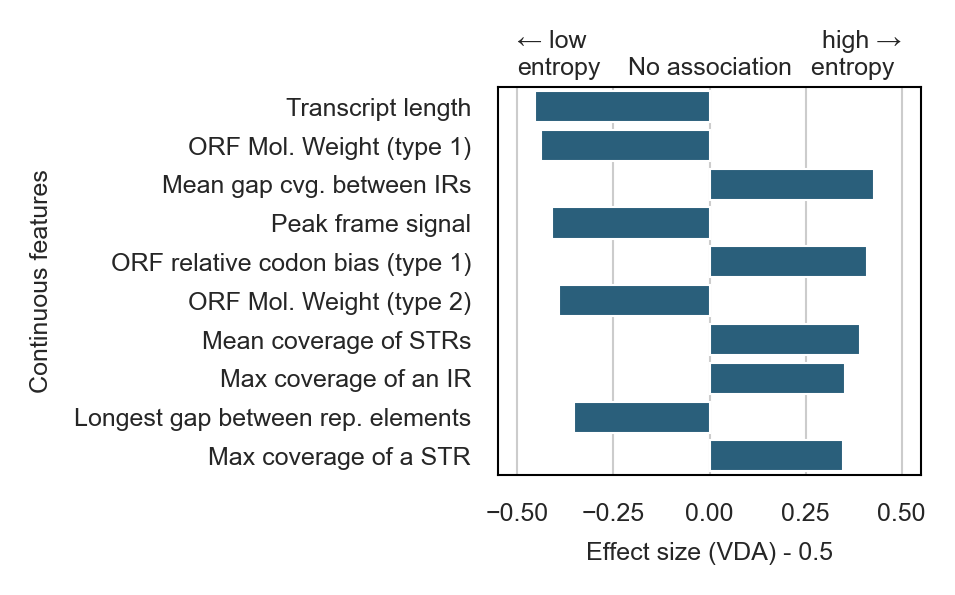

In [ ]:
# Select top 10 categorical features by Cramér's V
top10 = clustered_mannu.head(10)
top10["vda_to_plot"] = top10["vda"] - 0.5  # Center around 0 for better color mapping

top10['label'] = top10.index.map(mannu_dict)
top10['label'] = top10['label'].fillna(top10.index.to_series())  # Use index as label if not in dictionary

# Colors
norm = plt.Normalize(0, 0.6)
cmap = sns.color_palette("crest")
#cmap = sns.color_palette('RdYlBu_r', as_cmap=True)
#cmap = plt.cm.Blues

fig_h_cm = 5
fig_w_cm = 8

# Plot
fig, ax = plt.subplots(figsize=(fig_w_cm / 2.54 , fig_h_cm/2.54), dpi=300)
bar = sns.barplot(x=top10['vda_to_plot'], y=top10.index[::-1], ax=ax, color=sns.color_palette("crest")[-2])

y_pos = np.arange(len(top10))[::-1]  # highest rank at top
ax.set_yticks(y_pos)
ax.set_yticklabels(top10['label'][::-1])
ax.set_ylabel("Continuous features", labelpad=5)
ax.set_xlabel("Effect size (VDA) - 0.5")
#ax.set_title("Top 10 Categorical Features with association to\ncoding vs lncRNA in low entropy group", pad=30)
ax.set_xlim(-0.55, 0.55)
ax.set_xticks([-0.5, -0.25, 0, 0.25, 0.5])
#ax.set_xticklabels(['0.0', '0.25', '0.5', '0.75', '1.0'])

#Add annotation on top of graph with direction
#Right is pc, left is lncRNA, 0 shows no association
ax.text(0.5, 1.02, 'high →\nentropy ', ha='right', va='bottom', transform=ax.get_xaxis_transform())
ax.text(-0.5, 1.02, '← low\nentropy', ha='left', va='bottom', transform=ax.get_xaxis_transform())
ax.text(0, 1.02, 'No association', ha='center', va='bottom', transform=ax.get_xaxis_transform())

plt.savefig(os.path.join(FIGURE_DIR, "univariate_mannu_clustered_entropy.pdf"), dpi=300, format='pdf')

plt.tight_layout()
plt.show()

## Global plot

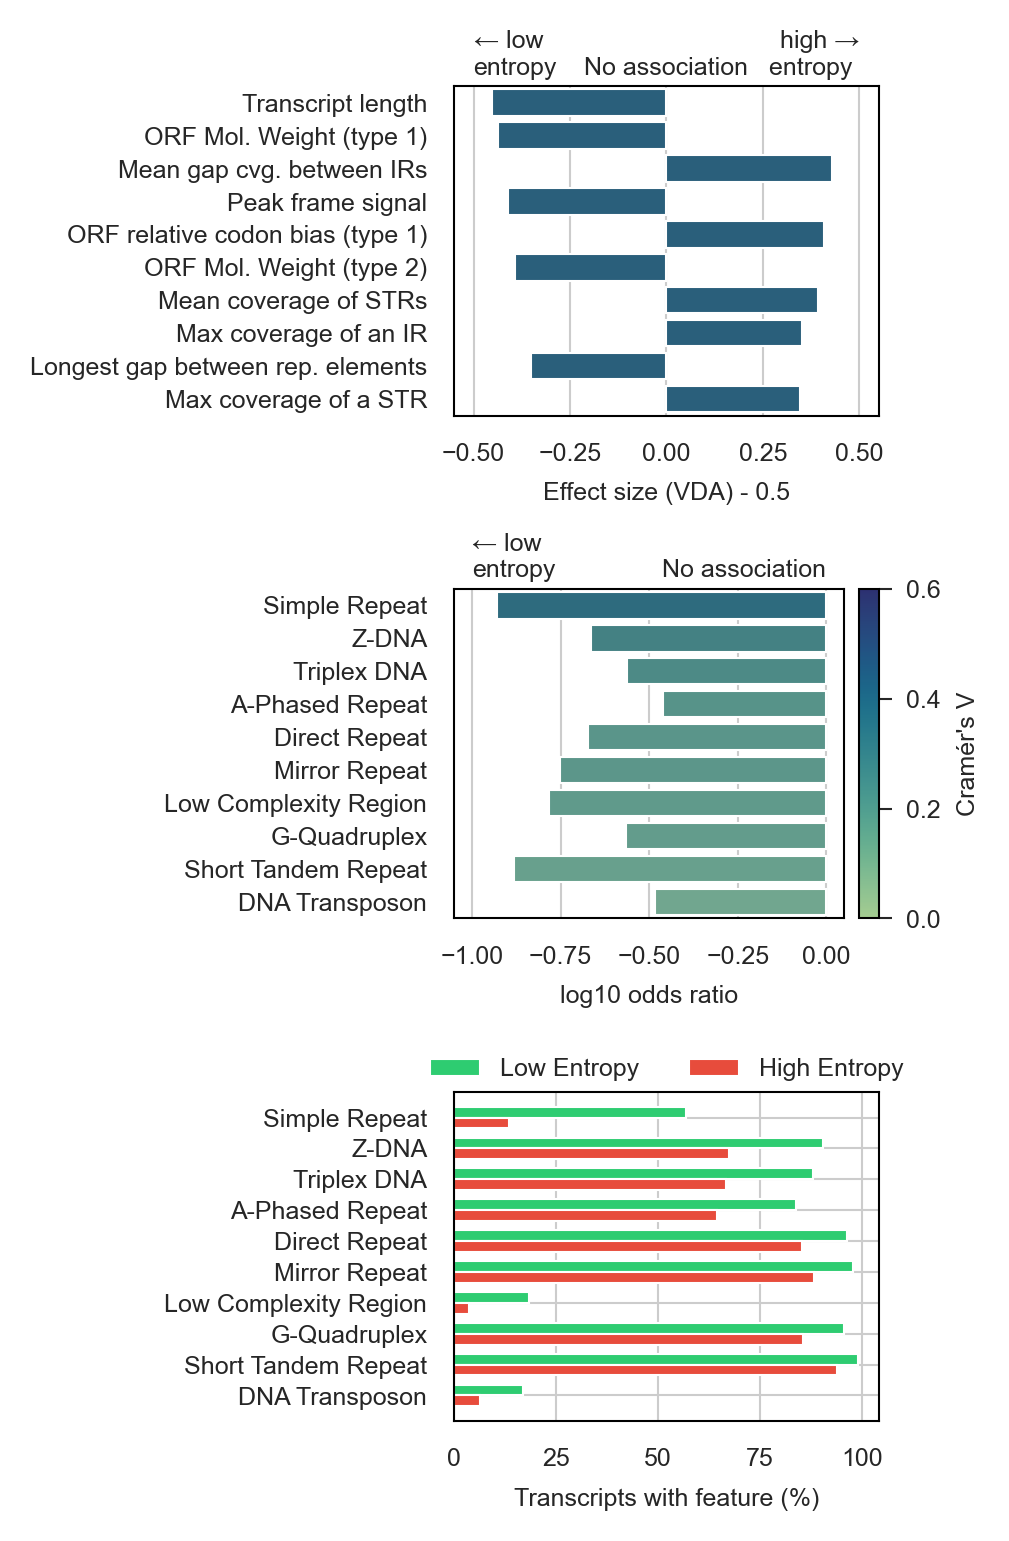

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create combined grid plot with three graphs vertically aligned
fig, axes = plt.subplots(3, 1, figsize=(8.5 / 2.54, 13 / 2.54), dpi=300)

# === Plot 1: Continuous variables after clustering ===
top10_cont = clustered_mannu.head(10)
top10_cont["vda_to_plot"] = top10_cont["vda"] - 0.5
top10_cont['label'] = top10_cont.index.map(mannu_dict)
top10_cont['label'] = top10_cont['label'].fillna(top10_cont.index.to_series())  # Use index as label if not in dictionary

sns.barplot(x=top10_cont['vda_to_plot'], y=top10_cont.index[::-1], ax=axes[0], color=sns.color_palette("crest")[-2])
axes[0].set_yticks(np.arange(len(top10_cont))[::-1])
axes[0].set_yticklabels(top10_cont['label'][::-1], fontsize=6)
axes[0].set_ylabel("", fontsize=6)
axes[0].set_xlabel("Effect size (VDA) - 0.5", fontsize=6)
axes[0].set_xlim(-0.55, 0.55)
axes[0].set_xticks([-0.5, -0.25, 0, 0.25, 0.5])
axes[0].text(0.5, 1.02, 'high →\nentropy ', ha='right', va='bottom', transform=axes[0].get_xaxis_transform(), fontsize=6)
axes[0].text(-0.5, 1.02, '← low\nentropy', ha='left', va='bottom', transform=axes[0].get_xaxis_transform(), fontsize=6)
axes[0].text(0, 1.02, 'No association', ha='center', va='bottom', transform=axes[0].get_xaxis_transform(), fontsize=6)

# === Plot 2: Categorical variables ===
top10_cat = chi2_df.sort_values('cramers_v', ascending=False).head(10).copy()
top10_cat['label'] = top10_cat.index.map(chi2_label_dict)
top10_cat["log10_odds_ratio"] = np.log10(top10_cat["odds_ratio"].replace(0, np.nan))

norm_cat = plt.Normalize(0, 0.6)
cmap_cat = sns.color_palette("crest", as_cmap=True)

sns.barplot(x=top10_cat['log10_odds_ratio'], y=top10_cat.index[::-1], hue=top10_cat['cramers_v'], 
            palette=cmap_cat, hue_norm=norm_cat, ax=axes[1])

axes[1].set_yticks(np.arange(len(top10_cat))[::-1])
axes[1].set_yticklabels(top10_cat['label'][::-1], fontsize=6)
axes[1].set_ylabel("", fontsize=6)
axes[1].set_xlabel("log10 odds ratio", fontsize=6)
axes[1].set_xlim(-1.05, 0.05)
axes[1].text(-1.0, 1.02, '← low\nentropy', ha='left', va='bottom', transform=axes[1].get_xaxis_transform(), fontsize=6)
axes[1].text(0, 1.02, 'No association', ha='right', va='bottom', transform=axes[1].get_xaxis_transform(), fontsize=6)
axes[1].get_legend().remove()

# Colorbar for categorical plot - using divider to keep axes aligned
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
sm = plt.cm.ScalarMappable(cmap=cmap_cat, norm=norm_cat)
cbar1 = plt.colorbar(sm, cax=cax)
cbar1.set_label("Cramér's V", fontsize=6)
cbar1.set_ticks([0, 0.2, 0.4, 0.6])
cbar1.ax.tick_params(labelsize=6)

# === Plot 3: Proportions ===
freq_df_plot = freq_df[['label', 'Low Entropy', 'High Entropy']].loc[top10_cat.index]

x_pos = np.arange(len(freq_df_plot))
width = 0.35

axes[2].barh(x_pos - width/2, freq_df_plot['Low Entropy'], width, label='Low Entropy', color='#2ecc71')
axes[2].barh(x_pos + width/2, freq_df_plot['High Entropy'], width, label='High Entropy', color='#e74c3c')

axes[2].set_yticks(x_pos)
axes[2].set_yticklabels(freq_df_plot['label'], fontsize=6)
axes[2].invert_yaxis()
axes[2].set_xlabel("Transcripts with feature (%)", fontsize=6)
axes[2].set_ylabel("", fontsize=6)
axes[2].legend(title="", loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol=2, frameon=False, fontsize=6)

# Adjust layout and save
plt.tight_layout()
plt.show()


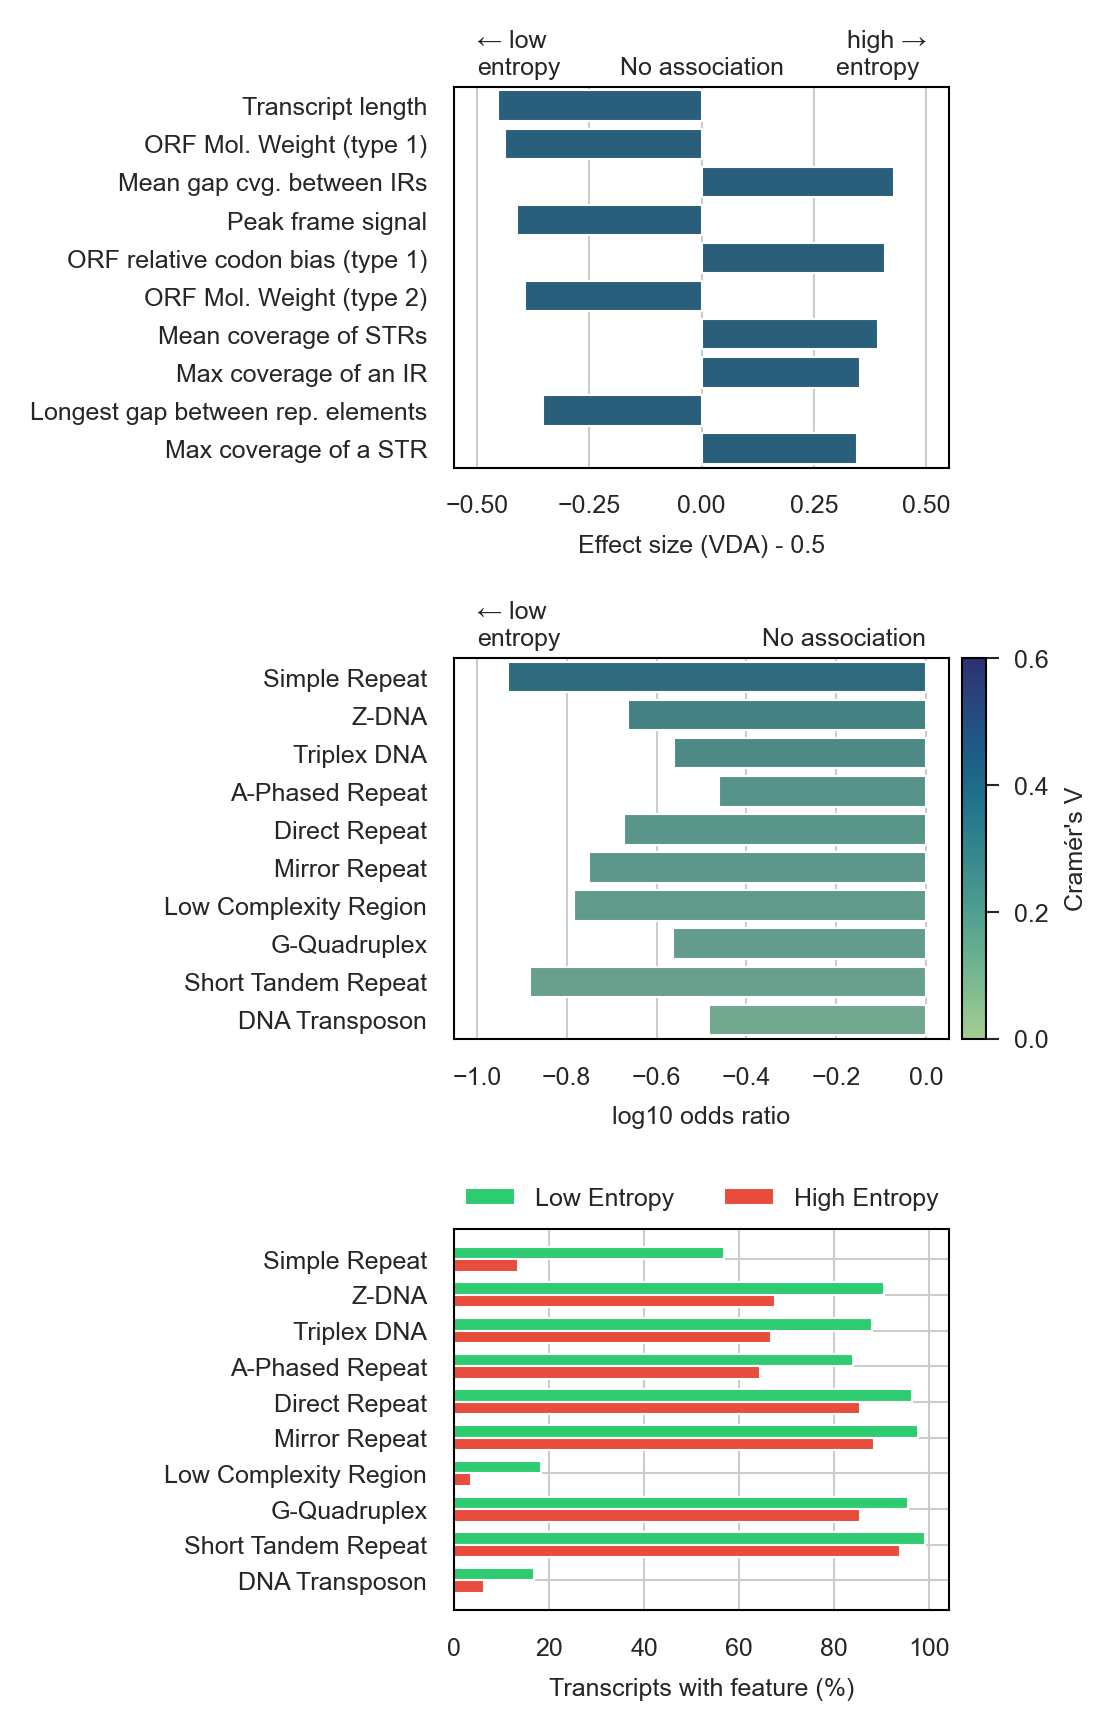

In [ ]:
import matplotlib.gridspec as gridspec

# Create combined grid plot with three graphs vertically aligned
# Use GridSpec to have explicit control over subplot widths
fig = plt.figure(figsize=(8.5 / 2.54, 15 / 2.54), dpi=300)
gs = gridspec.GridSpec(3, 2, figure=fig, width_ratios=[1, 0.05], wspace=0.05, hspace=0.5)

# Create main axes - all in the first column to ensure same width
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[2, 0])

# Create colorbar axis only for middle plot
cax = fig.add_subplot(gs[1, 1])

# === Plot 1: Continuous variables after clustering ===
top10_cont = clustered_mannu.head(10)
top10_cont["vda_to_plot"] = top10_cont["vda"] - 0.5
top10_cont['label'] = top10_cont.index.map(mannu_dict)

sns.barplot(x=top10_cont['vda_to_plot'], y=top10_cont.index[::-1], ax=ax0, color=sns.color_palette("crest")[-2])
ax0.set_yticks(np.arange(len(top10_cont))[::-1])
ax0.set_yticklabels(top10_cont['label'][::-1], fontsize=6)
ax0.set_ylabel("", fontsize=6)
ax0.set_xlabel("Effect size (VDA) - 0.5", fontsize=6)
ax0.set_xlim(-0.55, 0.55)
ax0.set_xticks([-0.5, -0.25, 0, 0.25, 0.5])
ax0.text(0.5, 1.02, 'high →\nentropy ', ha='right', va='bottom', transform=ax0.get_xaxis_transform(), fontsize=6)
ax0.text(-0.5, 1.02, '← low\nentropy', ha='left', va='bottom', transform=ax0.get_xaxis_transform(), fontsize=6)
ax0.text(0, 1.02, 'No association', ha='center', va='bottom', transform=ax0.get_xaxis_transform(), fontsize=6)

# === Plot 2: Categorical variables ===
top10_cat = chi2_df.sort_values('cramers_v', ascending=False).head(10).copy()
top10_cat['label'] = top10_cat.index.map(chi2_label_dict)
top10_cat["log10_odds_ratio"] = np.log10(top10_cat["odds_ratio"].replace(0, np.nan))

norm_cat = plt.Normalize(0, 0.6)
cmap_cat = sns.color_palette("crest", as_cmap=True)

sns.barplot(x=top10_cat['log10_odds_ratio'], y=top10_cat.index[::-1], hue=top10_cat['cramers_v'], 
            palette=cmap_cat, hue_norm=norm_cat, ax=ax1)

ax1.set_yticks(np.arange(len(top10_cat))[::-1])
ax1.set_yticklabels(top10_cat['label'][::-1], fontsize=6)
ax1.set_ylabel("", fontsize=6)
ax1.set_xlabel("log10 odds ratio", fontsize=6)
ax1.set_xlim(-1.05, 0.05)
ax1.text(-1.0, 1.02, '← low\nentropy', ha='left', va='bottom', transform=ax1.get_xaxis_transform(), fontsize=6)
ax1.text(0, 1.02, 'No association', ha='right', va='bottom', transform=ax1.get_xaxis_transform(), fontsize=6)
ax1.get_legend().remove()

# Colorbar for categorical plot in separate axis
sm = plt.cm.ScalarMappable(cmap=cmap_cat, norm=norm_cat)
cbar1 = plt.colorbar(sm, cax=cax)
cbar1.set_label("Cramér's V", fontsize=6)
cbar1.set_ticks([0, 0.2, 0.4, 0.6])
cbar1.ax.tick_params(labelsize=6)

# === Plot 3: Proportions ===
freq_df_plot = freq_df[['label', 'Low Entropy', 'High Entropy']].loc[top10_cat.index]

x_pos = np.arange(len(freq_df_plot))
width = 0.35

ax2.barh(x_pos - width/2, freq_df_plot['Low Entropy'], width, label='Low Entropy', color='#2ecc71')
ax2.barh(x_pos + width/2, freq_df_plot['High Entropy'], width, label='High Entropy', color='#e74c3c')

ax2.set_yticks(x_pos)
ax2.set_yticklabels(freq_df_plot['label'], fontsize=6)
ax2.invert_yaxis()
ax2.set_xlabel("Transcripts with feature (%)", fontsize=6)
ax2.set_ylabel("", fontsize=6)
ax2.legend(title="", loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol=2, frameon=False, fontsize=6)

# Save
fig.subplots_adjust(left=0.35, right=0.88, top=0.93, bottom=0.07, hspace=0.4)
plt.savefig(os.path.join(FIGURE_DIR, "combined_univariate_analysis_entropy.pdf"),
            dpi=300,
            format='pdf',
            bbox_inches='tight')
plt.show()
